**Q1.** What is Machine Learning? Explain the main types of Machine Learning with examples.

**Machine Learning (ML)** is a subset of artificial intelligence (AI) that focuses on building systems that learn from data, identify patterns, and make decisions or predictions with minimal human intervention. Instead of being explicitly programmed with rules, the algorithm improves its performance automatically through experience.

The three main types of Machine Learning are:

Supervised Learning: The algorithm is trained on labeled data, meaning each training example is paired with its correct output label.

Example: Email spam detection (predicting if an email is "Spam" or "Not Spam") or predicting house prices based on features.

Unsupervised Learning: The algorithm is given unlabeled data and must discover hidden patterns, structures, or groupings within the data on its own.

Example: Customer segmentation in e-commerce (grouping buyers by similar purchasing behaviors using clustering algorithms like K-Means).

Reinforcement Learning: An agent learns to make decisions by performing actions in an environment to maximize a cumulative reward through trial and error.

Example: Training an AI to play chess or developing self-driving car navigation controls.

**Q2.** What is Supervised Learning? Explain the difference between Regression and Classification.

**Ans:** Supervised Learning is a category of machine learning where a model learns a direct mapping from input variables ($X$) to an output target variable ($y$) based on an existing dataset that already contains ground-truth labels.The primary differences between Regression and Classification tasks are:Output Data Type: Regression models predict a continuous numerical value (infinite numeric possibilities). Classification models predict a discrete categorical value or class label (a finite set of groups).Core Goal: The goal of a Regression model is to predict a specific quantity or magnitude. The goal of a Classification model is to assign a given data point to a specific, predefined category.Common Examples: Regression examples include predicting house prices, stock market movements, or daily temperatures. Classification examples include detecting whether a credit card transaction is fraudulent or legitimate, or determining whether a medical image shows a benign or malignant growth.Evaluation Metrics: Regression models are evaluated using metrics like Mean Squared Error (MSE) and R-squared ($R^2$). Classification models are measured using metrics like Accuracy, Precision, Recall, and F1-Score

**Q3.** What is Linear Regression? Write the Linear Regression equation and explain intercept and coefficient.

**Ans:** Linear Regression is a parametric supervised learning algorithm used to model and analyze the direct linear relationship between a dependent target variable and one or more independent feature variables.The multiple linear regression equation is written as:$$y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \dots + \beta_n X_n + \epsilon$$$y$: The dependent/target variable being predicted (e.g., house price).$X_1, X_2, \dots, X_n$: The independent features used as inputs (e.g., crime rate, number of rooms, property tax).$\beta_0$ (Intercept): The value of the target variable $y$ when all input features ($X$) are exactly equal to zero. It sets the baseline height where the regression line crosses the vertical axis.$\beta_1, \beta_2, \dots, \beta_n$ (Coefficients/Weights): The slopes representing the expected change in the target variable $y$ for every one-unit increase in that specific independent variable $X$, assuming all other features in the model are held perfectly constant.$\epsilon$ (Error/Residual term): The random variance or noise in the real-world data that cannot be explained by the linear relationship.

**Q4.** Explain the following evaluation metrics used in Linear Regression

**Ans:** SSE (Sum of Squared Errors): The total sum of the quared differences between the actual observed values and the values predicted by the regression line. It measures the absolute baseline variance left unexplained by the model.
$$SSE = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$MSE (Mean Squared Error): The average of the squared errors between actual and predicted values. Because it squares the errors, it severely penalizes larger mistakes or outliers in the data.
$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$RMSE (Root Mean Squared Error): The square root of the Mean Squared Error. Taking the square root maps the metric back to the original units of your target variable, making it vastly easier to interpret practically.
$$RMSE = \sqrt{MSE}$$$R^2$ Score (Coefficient of Determination): A metric indicating the proportion of variance in the dependent variable that is predictable from the independent variables. It ranges from 0 to 1, where 1 indicates that the model perfectly explains all the data variance.
$$R^2 = 1 - \frac{SSE}{SST}$$Adjusted $R^2$: An altered version of $R^2$ that accounts for the total number of predictors added to a model. Unlike standard $R^2$, it will only increase if a newly added feature improves the model's predictive power more than what would be expected purely by statistical chance, effectively penalizing unnecessary model complexity.
$$\text{Adjusted } R^2 = 1 - \left[ \frac{(1 - R^2)(n - 1)}{n - p - 1} \right]$$(where $n$ is the total number of samples and $p$ is the total number of features)

**Q5.** Explain the Machine Learning workflow steps from data collection to model evaluation.

**Ans:** Data Collection: Gathering the raw structured or unstructured data from available repositories, SQL databases, files, APIs, or scraping engines.

Data Preprocessing & Cleaning: Rectifying structural data issues by handling missing values, removing duplicate data rows, managing extreme outliers, scaling features, and converting categorical variables to numeric values.

Exploratory Data Analysis (EDA): Analyzing the underlying data visually and statistically (using distributions, correlation calculations, heatmaps, and pairplots) to identify meaningful trends and hidden relationships.

Feature Selection & Engineering: Keeping the most influential independent features while dropping redundant, uninformative, or highly multi-collinear variables to avoid model degradation.

Data Splitting: Splitting the cleaned data into distinct Training (e.g., 80%) and Testing (e.g., 20%) sub-datasets to establish an accurate setup for verifying generalization capability.

Model Training: Running the training data subset through your chosen learning algorithm (like Linear Regression) so it can compute its optimal internal weights and intercepts.

Predictions & Model Evaluation: Running predictions on the unseen testing data partition and calculating key evaluation metrics (MAE, MSE, RMSE, $R^2$) to verify model accuracy before real-world usage.




In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [5]:
# Q6. Load the Boston Housing dataset and perform basic data exploration using:
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]
feature_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
df = pd.DataFrame(data, columns=feature_names)
df['medv'] = target # Appending the house price target column


<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_961/1926064161.py:3: SyntaxWarning: invalid escape sequence '\s'
  raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)


In [6]:
# 1.head()
print(df.head())


      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900  1.0  296.0   
1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671  2.0  242.0   
2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671  2.0  242.0   
3  0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622  3.0  222.0   
4  0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622  3.0  222.0   

   PTRATIO       B  LSTAT  medv  
0     15.3  396.90   4.98  24.0  
1     17.8  396.90   9.14  21.6  
2     17.8  392.83   4.03  34.7  
3     18.7  394.63   2.94  33.4  
4     18.7  396.90   5.33  36.2  


In [7]:
# 2. info()
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(14)
memory usage: 55.5 KB
None


In [8]:
# 3. describe()
print(df.describe())

             CRIM          ZN       INDUS        CHAS         NOX          RM  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean     3.613524   11.363636   11.136779    0.069170    0.554695    6.284634   
std      8.601545   23.322453    6.860353    0.253994    0.115878    0.702617   
min      0.006320    0.000000    0.460000    0.000000    0.385000    3.561000   
25%      0.082045    0.000000    5.190000    0.000000    0.449000    5.885500   
50%      0.256510    0.000000    9.690000    0.000000    0.538000    6.208500   
75%      3.677083   12.500000   18.100000    0.000000    0.624000    6.623500   
max     88.976200  100.000000   27.740000    1.000000    0.871000    8.780000   

              AGE         DIS         RAD         TAX     PTRATIO           B  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean    68.574901    3.795043    9.549407  408.237154   18.455534  356.674032   
std     28.148861    2.1057

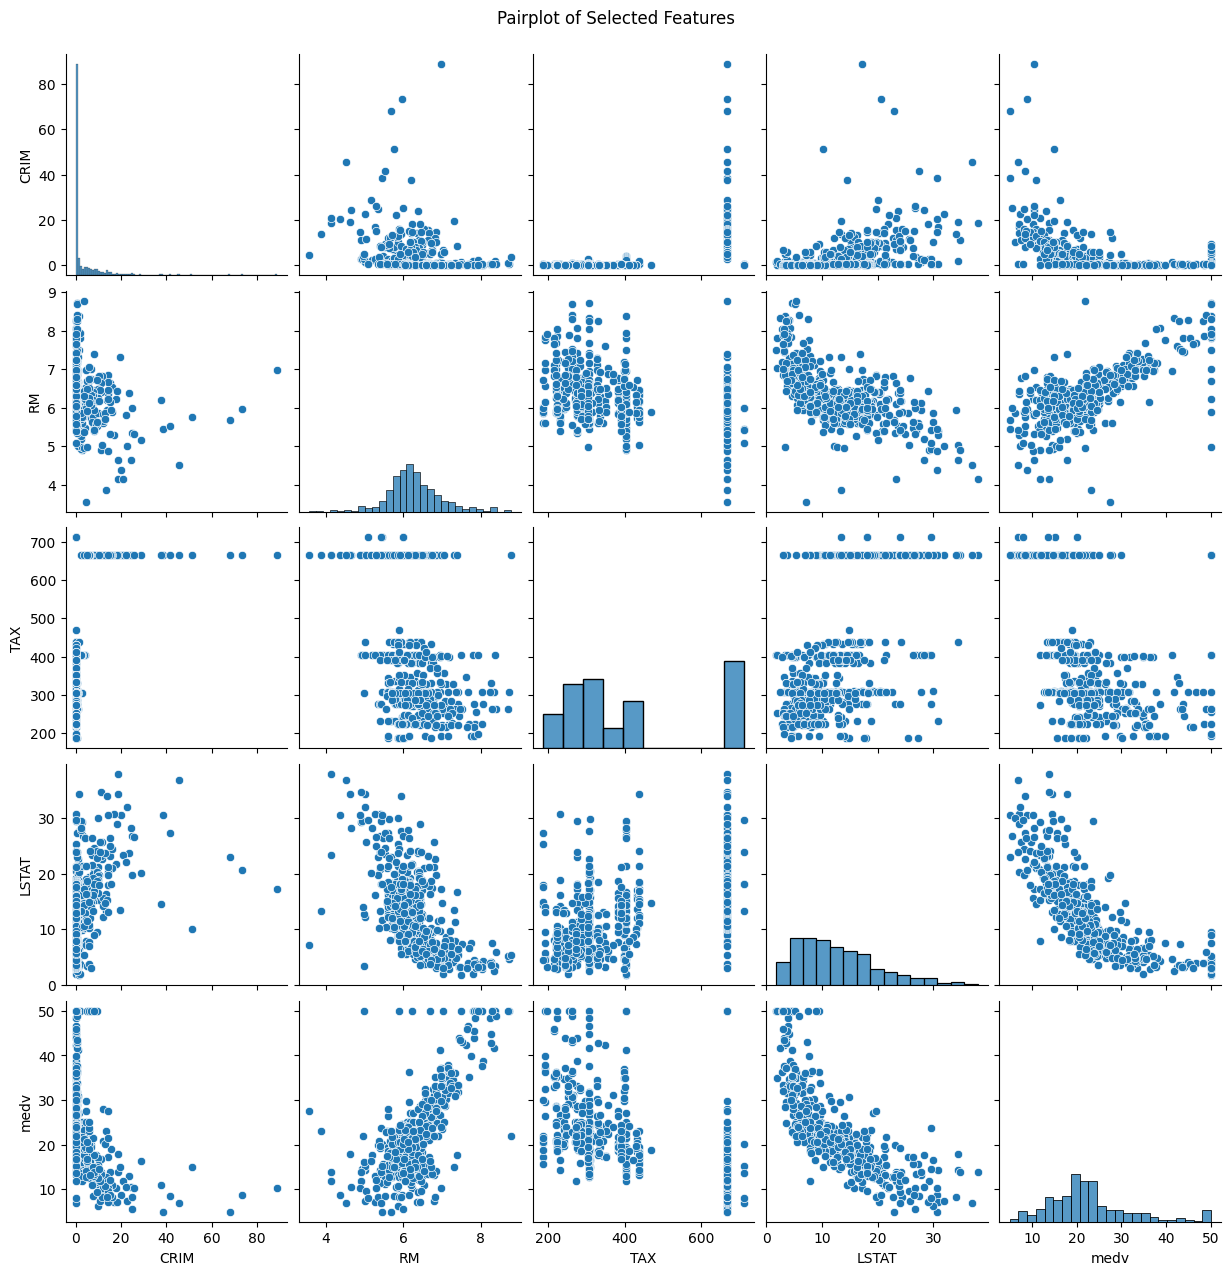

In [9]:
# Q7. Perform Exploratory Data Analysis:
# 1. Create pairplot
sns.pairplot(df[['CRIM', 'RM', 'TAX', 'LSTAT', 'medv']])
plt.suptitle('Pairplot of Selected Features', y=1.02)
plt.show()

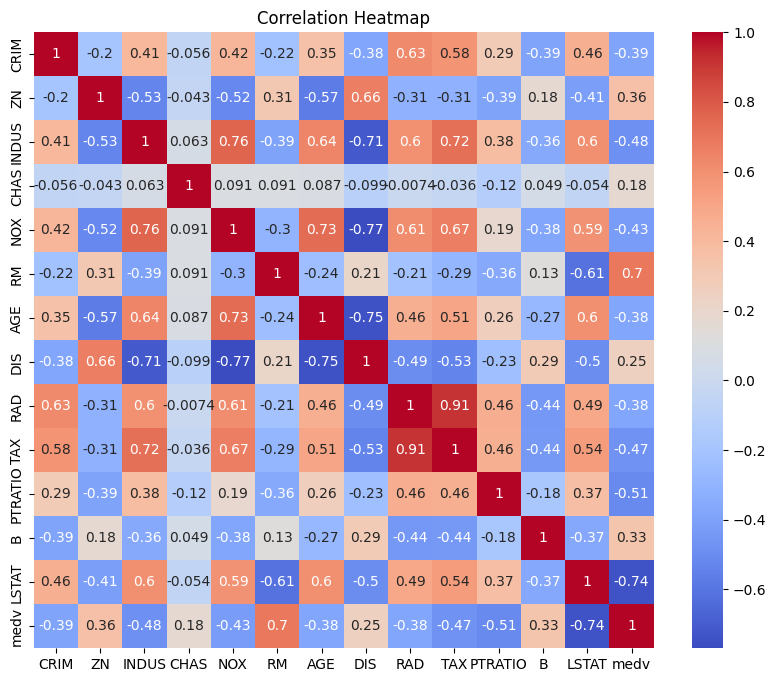

In [10]:
# Create correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [11]:
# Identify which features are highly correlated with house price (medv)
correlation_matrix = df.corr()
correlation_with_target = correlation_matrix['medv'].sort_values(ascending=False)
print("Correlation with House Price (medv):")
print(correlation_with_target)


Correlation with House Price (medv):
medv       1.000000
RM         0.695360
ZN         0.360445
B          0.333461
DIS        0.249929
CHAS       0.175260
AGE       -0.376955
RAD       -0.381626
CRIM      -0.388305
NOX       -0.427321
TAX       -0.468536
INDUS     -0.483725
PTRATIO   -0.507787
LSTAT     -0.737663
Name: medv, dtype: float64


In [13]:
# Q8. Select independent variables (features) and dependent variable (target).
X = df.drop(columns=['medv'])
Y = df['medv']


In [14]:
# Q9. Split the dataset into training and testing sets (80% training, 20% testing).
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Y_train shape:", Y_train.shape)
print("Y_test shape:", Y_test.shape)

X_train shape: (404, 13)
X_test shape: (102, 13)
Y_train shape: (404,)
Y_test shape: (102,)


In [15]:
# Q10: Model Training & Metric Evaluation Outputs
model = LinearRegression()
model.fit(X_train, Y_train)

LinearRegression()

In [16]:
# Executing test set predictions
y_pred = model.predict(X_test)

In [24]:
# Metrics calculation
mse = mean_squared_error(Y_test, y_pred)
xr2 = r2_score(Y_test, y_pred)

In [32]:
# Calculating Adjusted R-squared metric manually
n = X_test.shape[0]
p = X_test.shape[1]
adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

print("\n--- Model Performance Evaluation Metrics ---")
print(f"Mean Absolute Error (MAE):     {mae:.4f}")
print(f"Mean Squared Error (MSE):      {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score:                       {r2:.4f}")
print(f"Adjusted R² Score:              {adjusted_r2:.4f}")


--- Model Performance Evaluation Metrics ---
Mean Absolute Error (MAE):     3.1891
Mean Squared Error (MSE):      24.2911
Root Mean Squared Error (RMSE): 4.9286
R² Score:                       0.6688
Adjusted R² Score:              0.6198


In [35]:
# Generating the textual Linear Regression formula output
intercept = model.intercept_
coefficients = model.coef_
equation_parts = [f"{intercept:.4f}"]
for feat, coef in zip(feature_names, coefficients):
    equation_parts.append(f"({coef:.4f} * {feat})")
equation_str = "medv = " + " + ".join(equation_parts)

print("\n---  Textual Linear Regression Equation ---")
print(equation_str)

print("\n---  Individual Feature Coefficient Interpretation ---")
for feat, coef in zip(feature_names, coefficients):
    print(f"Feature '{feat}': A single unit increase alters 'medv' by {coef:.4f} units, assuming all other independent variables are held perfectly constant.")


---  Textual Linear Regression Equation ---
medv = 30.2468 + (-0.1131 * CRIM) + (0.0301 * ZN) + (0.0404 * INDUS) + (2.7844 * CHAS) + (-17.2026 * NOX) + (4.4388 * RM) + (-0.0063 * AGE) + (-1.4479 * DIS) + (0.2624 * RAD) + (-0.0106 * TAX) + (-0.9155 * PTRATIO) + (0.0124 * B) + (-0.5086 * LSTAT)

---  Individual Feature Coefficient Interpretation ---
Feature 'CRIM': A single unit increase alters 'medv' by -0.1131 units, assuming all other independent variables are held perfectly constant.
Feature 'ZN': A single unit increase alters 'medv' by 0.0301 units, assuming all other independent variables are held perfectly constant.
Feature 'INDUS': A single unit increase alters 'medv' by 0.0404 units, assuming all other independent variables are held perfectly constant.
Feature 'CHAS': A single unit increase alters 'medv' by 2.7844 units, assuming all other independent variables are held perfectly constant.
Feature 'NOX': A single unit increase alters 'medv' by -17.2026 units, assuming all other